# CFP linear vs MLP scoring on the original screws segmentation dataset

This notebook compares the default linear sigmoid scorer with a small MLP scorer on the original screws segmentation dataset. The inputs and masks come from the paired `*_in` and `*_target` files. The experiment uses a loss designed for sparse foreground masks and calibrates the response threshold on the training split before reporting test F1.


## Setup

Resolve the local checkout, import the libraries, fix the random seed, and select the best available device.


In [11]:
#!pip install mtlearn

from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
generator = torch.Generator(device="cpu").manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)


device: mps


## Experiment configuration

The CFP layers use the same max-tree and attribute set. They differ only in the scoring model: one linear sigmoid scorer and one nonlinear MLP scorer. The supervised target is the original annotated screw mask loaded from the dataset.

The foreground occupies only a small fraction of the image, so the training loss combines soft Dice with foreground-balanced BCE. The reported `test_f1` uses a threshold selected on the training split; `test_f1_fixed` keeps the uncalibrated threshold `0.5` as a reference.


In [21]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0
RESPONSE_THRESHOLD = 0.5
THRESHOLD_GRID = [round(value, 2) for value in np.linspace(0.05, 0.95, 91)]

TREE_TYPE = "max-tree"
TREE_ENUM = morphology.TreeType.MAX_TREE

Type = morphology.AttributeType
#FILTER_ATTRIBUTES = (
#    Type.AREA,
#    Type.LENGTH_MAJOR_AXIS,
#    Type.LENGTH_MINOR_AXIS,
#    Type.INERTIA,
#    Type.CIRCULARITY,
#    Type.GRAY_HEIGHT,
#    Type.RECTANGULARITY,
#)

#all attributes
FILTER_ATTRIBUTES = (morphology.AttributeGroup.ALL,)

SCORE_SHARPNESS = 1.0
CLAMP_LOGIT = 12.0
IDENTITY_P0 = 0.995
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-7
GRAD_CLIP = 5.0
NUM_EPOCHS = 100
REPORT_EPOCHS = {1, 5, 10, 20, 50, 100}
DICE_LOSS_WEIGHT = 0.5
BCE_LOSS_WEIGHT = 0.5
MLP_HIDDEN_UNITS = [8]
MLP_ACTIVATION = "tanh"

config = {
    "task": "segmentation",
    "dataset": DATASET_NAME,
    "tree": TREE_TYPE,
    "input_size": f"{NUM_ROWS}x{NUM_COLS}",
    "target_source": "original paired *_target masks",
    "filter_attributes": [attribute.name for attribute in FILTER_ATTRIBUTES],
    "linear_scoring": {"kind": "linear_sigmoid"},
    "mlp_scoring": {"kind": "mlp", "hidden_units": MLP_HIDDEN_UNITS, "activation": MLP_ACTIVATION},
    "scale_mode": "dataset_clipped_zscore01",
    "score_sharpness": SCORE_SHARPNESS,
    "loss": "0.5 * soft_dice + 0.5 * foreground_balanced_bce",
    "threshold_selection": "best train F1 over [0.05, 0.95]",
    "fixed_response_threshold": RESPONSE_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
}
display(pd.DataFrame([config]))


,task,dataset,tree,input_size,target_source,filter_attributes,linear_scoring,mlp_scoring,scale_mode,score_sharpness,loss,threshold_selection,fixed_response_threshold,learning_rate,num_epochs
0,segmentation,screws_segmentation,max-tree,256x256,original paired *_target masks,[ALL],{'kind': 'linear_sigmoid'},"{'kind': 'mlp', 'hidden_units': [8], 'activati...",dataset_clipped_zscore01,1.0,0.5 * soft_dice + 0.5 * foreground_balanced_bce,"best train F1 over [0.05, 0.95]",0.5,0.01,100


## Dataset

The original screws dataset stores each input image and its annotated target mask as a file pair. The inputs and masks are resized to the experiment resolution, converted to grayscale tensors, inverted to match the segmentation convention used by the screws notebooks, and scaled to `[0, 1]`.


screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
trainset: 34
testset: 15
train foreground fraction: 0.0197
positive BCE weight: 49.693


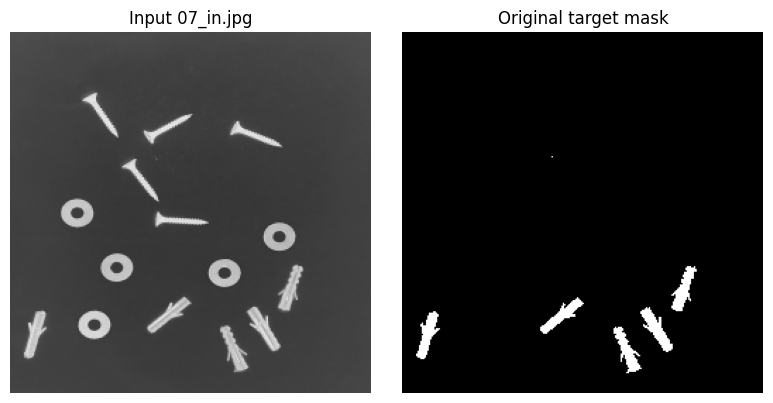

In [15]:
dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    grayscale_in=True,
    grayscale_target=True,
    invert_in=True,
    invert_target=True,
    scale_in=True,
    scale_out=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("trainset:", len(trainset))
print("testset:", len(testset))

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

positive_pixels = 0
total_pixels = 0
for _, target, _ in trainset:
    mask = target >= 0.5
    positive_pixels += int(mask.sum().item())
    total_pixels += int(mask.numel())

FOREGROUND_FRACTION = positive_pixels / total_pixels
POSITIVE_BCE_WEIGHT = (total_pixels - positive_pixels) / max(positive_pixels, 1)
print(f"train foreground fraction: {FOREGROUND_FRACTION:.4f}")
print(f"positive BCE weight: {POSITIVE_BCE_WEIGHT:.3f}")

image_in, image_target, name = trainset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_in.squeeze().detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input {name}")
axes[1].imshow(image_target.squeeze().detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Original target mask")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


## CFP layers

Both CFP layers use the same morphology tree, attributes, normalization, `score_sharpness`, and initialization. Only the scoring model changes.


In [16]:
def make_filter_spec(name, scoring):
    return {
        "name": name,
        "tree_type": TREE_ENUM,
        "attributes": FILTER_ATTRIBUTES,
        "score_sharpness": SCORE_SHARPNESS,
        "scoring": scoring,
    }


def make_layer(spec_name, scoring):
    return ConnectedFilterPreprocessingLayer(
        in_channels=1,
        filter_specs=[make_filter_spec(spec_name, scoring)],
        scale_mode="dataset_clipped_zscore01",
        device=device,
        clamp=CLAMP_LOGIT,
    )


cfp_layers = {
    "Linear scoring": make_layer("linear_scoring", {"kind": "linear_sigmoid"}),
    "Nonlinear MLP scoring": make_layer(
        "nonlinear_mlp_scoring",
        {"kind": "mlp", "hidden_units": MLP_HIDDEN_UNITS, "activation": MLP_ACTIVATION},
    ),
}

cached_loaders = {}
layer_rows = []
for model_name, layer in cfp_layers.items():
    print(f"Building CFP caches for {model_name}...")
    train_cached = layer.build_dataloader_cached(trainloader)
    test_cached = layer.build_dataloader_cached_fixed_stats(
        testloader,
        index_offset=len(trainset),
    )
    layer.init_identity(p0=IDENTITY_P0)
    cached_loaders[model_name] = {"train": train_cached, "test": test_cached}
    spec_config = layer.get_config()["filter_specs"][0]
    layer_rows.append(
        {
            "model": model_name,
            "filter_name": spec_config["name"],
            "scoring": spec_config["scoring"],
            "parameter_contract": layer.get_parameter_contract(),
        }
    )

display(pd.DataFrame(layer_rows))


Building CFP caches for Linear scoring...
Building CFP caches for Nonlinear MLP scoring...


,model,filter_name,scoring,parameter_contract
0,Linear scoring,linear_scoring,{'kind': 'linear_sigmoid'},"{'weights': {'linear_scoring': [64]}, 'biases'..."
1,Nonlinear MLP scoring,nonlinear_mlp_scoring,"{'kind': 'mlp', 'hidden_units': [8], 'activati...","{'weights': {}, 'biases': {}, 'scoring_models'..."


## Evaluation utilities

The CFP layer returns an image-like response, not a calibrated probability map. We normalize each response image to `[0, 1]`, optimize the training loss on that response, and select the segmentation threshold on the training split. Test F1 is then computed with the train-selected threshold.


In [17]:
def normalize_per_image(batch):
    dims = tuple(range(2, batch.ndim))
    low = batch.amin(dim=dims, keepdim=True)
    high = batch.amax(dim=dims, keepdim=True)
    return (batch - low) / torch.clamp(high - low, min=1e-6)


def soft_dice_loss(probabilities, targets, eps=1e-6):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probs = probabilities.reshape(probabilities.size(0), -1)
    masks = targets.reshape(targets.size(0), -1)
    intersection = torch.sum(probs * masks, dim=1)
    denominator = torch.sum(probs, dim=1) + torch.sum(masks, dim=1)
    return (1.0 - (2.0 * intersection + eps) / (denominator + eps)).mean()


def balanced_bce_loss(probabilities, targets):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probabilities = probabilities.clamp(1e-4, 1.0 - 1e-4)
    pixel_loss = F.binary_cross_entropy(probabilities, targets, reduction="none")
    positive_weight = torch.as_tensor(
        POSITIVE_BCE_WEIGHT,
        device=probabilities.device,
        dtype=probabilities.dtype,
    )
    pixel_weight = torch.where(targets >= 0.5, positive_weight, torch.ones_like(targets))
    return torch.mean(pixel_loss * pixel_weight)


def segmentation_loss(probabilities, targets):
    return (
        DICE_LOSS_WEIGHT * soft_dice_loss(probabilities, targets)
        + BCE_LOSS_WEIGHT * balanced_bce_loss(probabilities, targets)
    )


def collect_responses_and_targets(layer, dataloader):
    was_training = layer.training
    layer.eval()
    responses = []
    targets = []

    with torch.no_grad():
        for batch_inputs, batch_targets in dataloader:
            response = normalize_per_image(layer(batch_inputs) / OUTPUT_SCALE)
            responses.append(response.detach().cpu())
            targets.append(batch_targets.detach().cpu())

    layer.train(was_training)
    return torch.cat(responses, dim=0), torch.cat(targets, dim=0)


def metrics_from_responses(responses, targets, threshold):
    prediction = responses >= threshold
    target = targets >= 0.5

    tp = torch.sum(prediction & target).item()
    fp = torch.sum(prediction & ~target).item()
    fn = torch.sum(~prediction & target).item()
    tn = torch.sum(~prediction & ~target).item()

    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "threshold": float(threshold),
        "iou": tp / (tp + fp + fn + eps),
        "f1": 2.0 * precision * recall / (precision + recall + eps),
        "precision": precision,
        "recall": recall,
        "accuracy": (tp + tn) / (tp + fp + fn + tn + eps),
        "foreground_fraction": (tp + fn) / (tp + fp + fn + tn + eps),
    }


def best_f1_threshold(responses, targets):
    threshold_rows = [
        metrics_from_responses(responses, targets, threshold)
        for threshold in THRESHOLD_GRID
    ]
    return max(threshold_rows, key=lambda row: row["f1"])


def parameter_summary(layer):
    with torch.no_grad():
        total_sq = torch.zeros((), device=device)
        total_params = 0
        for parameter in layer.parameters():
            total_sq = total_sq + torch.sum(parameter.detach().to(device=device).float().square())
            total_params += parameter.numel()
        summary = {
            "num_parameters": int(total_params),
            "parameter_l2": float(torch.sqrt(total_sq).detach().cpu()),
        }
        if len(layer._weights) == 1:
            key = next(iter(layer._weights.keys()))
            summary["linear_weight_l2"] = float(torch.linalg.vector_norm(layer._weights[key].detach()).cpu())
            summary["linear_bias"] = float(layer._biases[key].detach().cpu().view(-1)[0])
        return summary


selected_thresholds = {}


def collect_metrics(epoch, model_name, layer, train_loss=None):
    train_responses, train_targets = collect_responses_and_targets(layer, cached_loaders[model_name]["train"])
    test_responses, test_targets = collect_responses_and_targets(layer, cached_loaders[model_name]["test"])

    train_threshold_metrics = best_f1_threshold(train_responses, train_targets)
    selected_threshold = train_threshold_metrics["threshold"]
    selected_thresholds[model_name] = selected_threshold

    train_metrics = metrics_from_responses(train_responses, train_targets, selected_threshold)
    test_metrics = metrics_from_responses(test_responses, test_targets, selected_threshold)
    train_fixed_metrics = metrics_from_responses(train_responses, train_targets, RESPONSE_THRESHOLD)
    test_fixed_metrics = metrics_from_responses(test_responses, test_targets, RESPONSE_THRESHOLD)

    row = {
        "epoch": int(epoch),
        "model": model_name,
        "learning_rate": LEARNING_RATE,
        "threshold": selected_threshold,
        "train_loss": float(segmentation_loss(train_responses, train_targets).detach().cpu()),
        "test_loss": float(segmentation_loss(test_responses, test_targets).detach().cpu()),
        "train_f1_fixed": train_fixed_metrics["f1"],
        "test_f1_fixed": test_fixed_metrics["f1"],
    }
    if train_loss is not None:
        row["train_epoch_loss"] = float(train_loss)
    row.update(parameter_summary(layer))
    row.update({f"train_{key}": value for key, value in train_metrics.items()})
    row.update({f"test_{key}": value for key, value in test_metrics.items()})
    return row


def show_segmentation_comparison(epoch):
    model_items = list(cfp_layers.items())
    first_inputs, viz_targets = next(iter(cached_loaders[model_items[0][0]]["test"]))
    viz_images = first_inputs[0] if isinstance(first_inputs, (tuple, list)) else first_inputs

    ncols = 2 + 2 * len(model_items)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
    axes[0].imshow(viz_images[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input")
    axes[1].imshow(viz_targets[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Target mask")

    col = 2
    for model_name, layer in model_items:
        model_inputs, _ = next(iter(cached_loaders[model_name]["test"]))
        threshold = selected_thresholds.get(model_name, RESPONSE_THRESHOLD)
        was_training = layer.training
        layer.eval()
        with torch.no_grad():
            response = normalize_per_image(layer(model_inputs) / OUTPUT_SCALE)
            prediction = response >= threshold
        layer.train(was_training)

        axes[col].imshow(response[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[col].set_title(f"{model_name}\nresponse")
        axes[col + 1].imshow(prediction[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[col + 1].set_title(f"{model_name}\nprediction t={threshold:.2f}")
        col += 2

    for axis in axes:
        axis.axis("off")
    fig.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()


## Initial state

Both CFP layers are initialized close to the identity. The table reports train/test segmentation metrics before any optimizer update.


,epoch,model,learning_rate,threshold,train_loss,test_loss,train_f1_fixed,test_f1_fixed,num_parameters,parameter_l2,...,train_recall,train_accuracy,train_foreground_fraction,test_threshold,test_iou,test_f1,test_precision,test_recall,test_accuracy,test_foreground_fraction
0,0,Linear scoring,0.01,0.52,0.644072,0.643383,0.484673,0.483108,65,5.293305,...,0.896713,0.962482,0.019726,0.52,0.318625,0.483268,0.330584,0.89804,0.962427,0.019565
1,0,Nonlinear MLP scoring,0.01,0.52,0.644072,0.643383,0.484621,0.483094,529,5.546021,...,0.896713,0.962482,0.019726,0.52,0.318625,0.483268,0.330584,0.89804,0.962427,0.019565


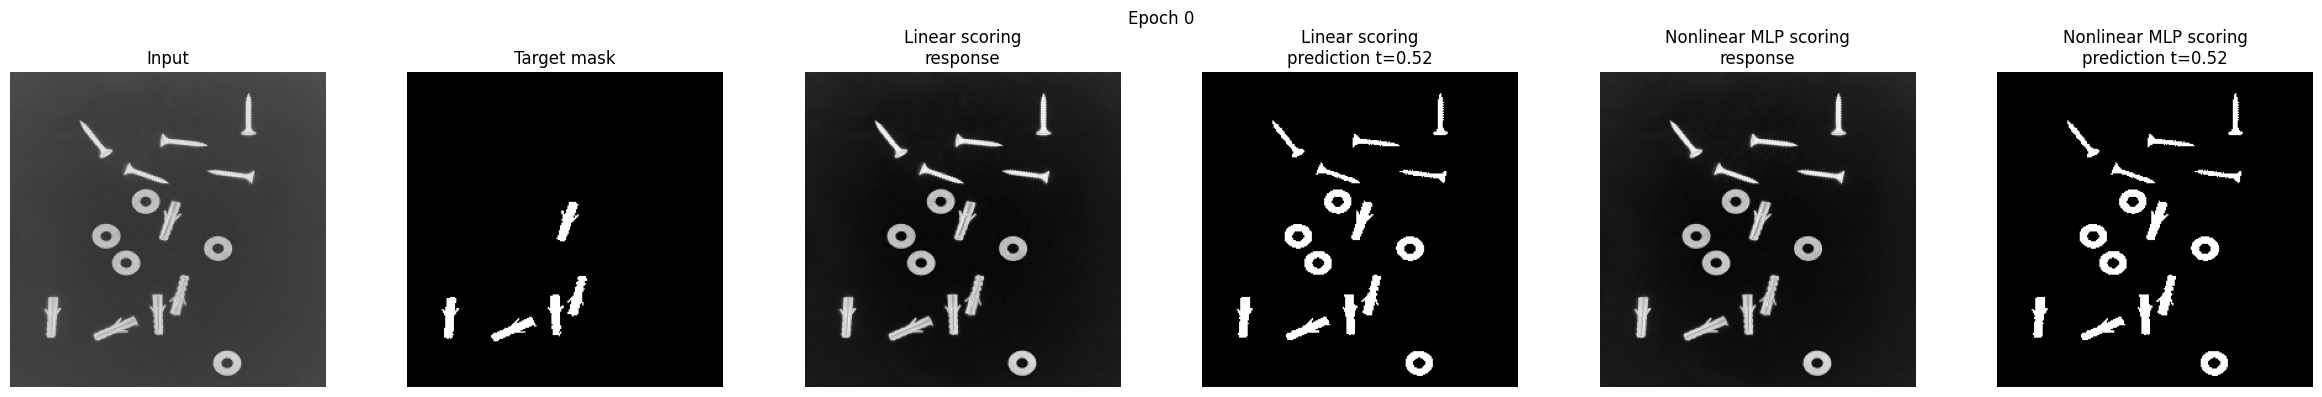

In [18]:
initial_rows = [
    collect_metrics(0, model_name, layer)
    for model_name, layer in cfp_layers.items()
]
initial_table = pd.DataFrame(initial_rows)
display(initial_table)
show_segmentation_comparison(epoch=0)


## Training

Each model is trained with the same optimizer and the same loss. The training loss is differentiable, while F1 is reported after threshold calibration on the train split.


,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,1,Linear scoring,0.644335,0.54,0.484739,0.483063,0.485333,0.483577,0.320422,0.318893
1,1,Nonlinear MLP scoring,0.644582,0.52,0.484664,0.483132,0.485323,0.483268,0.320413,0.318625


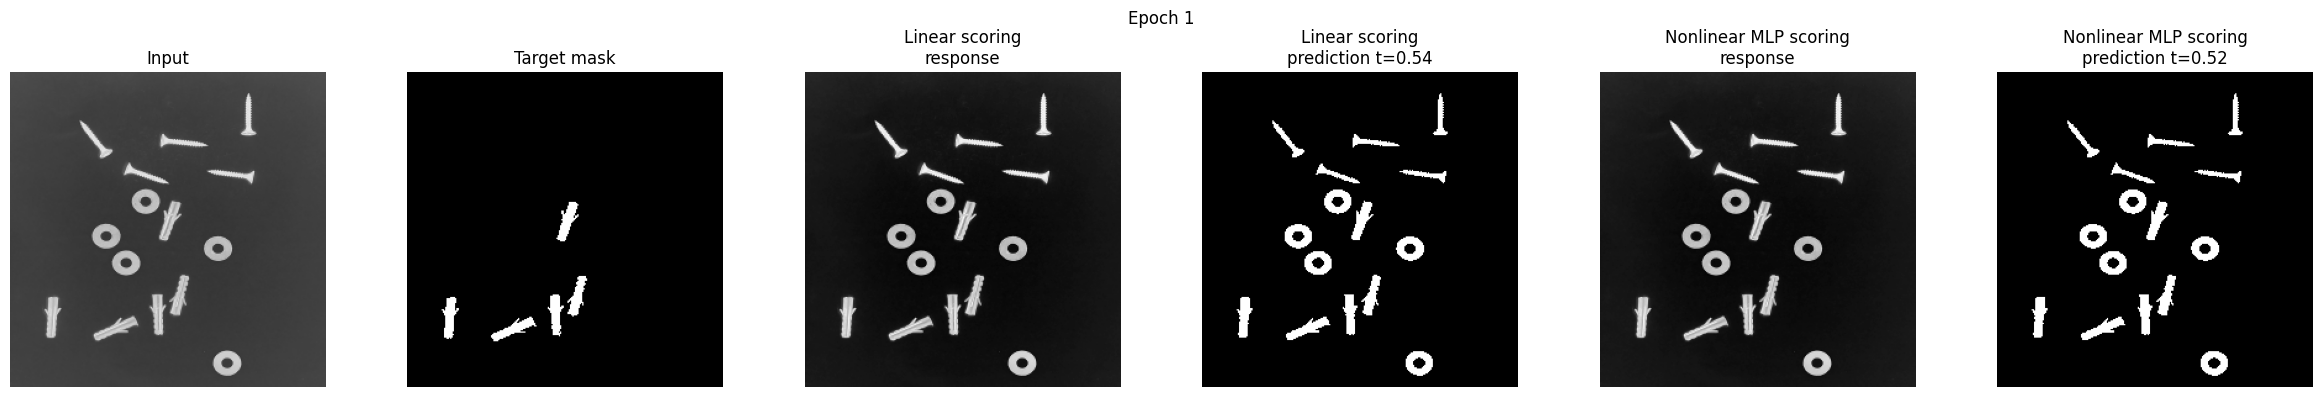

,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,5,Linear scoring,0.557288,0.45,0.483071,0.481588,0.485072,0.483348,0.320195,0.318694
1,5,Nonlinear MLP scoring,0.641248,0.54,0.484827,0.483309,0.485763,0.483811,0.320797,0.319097


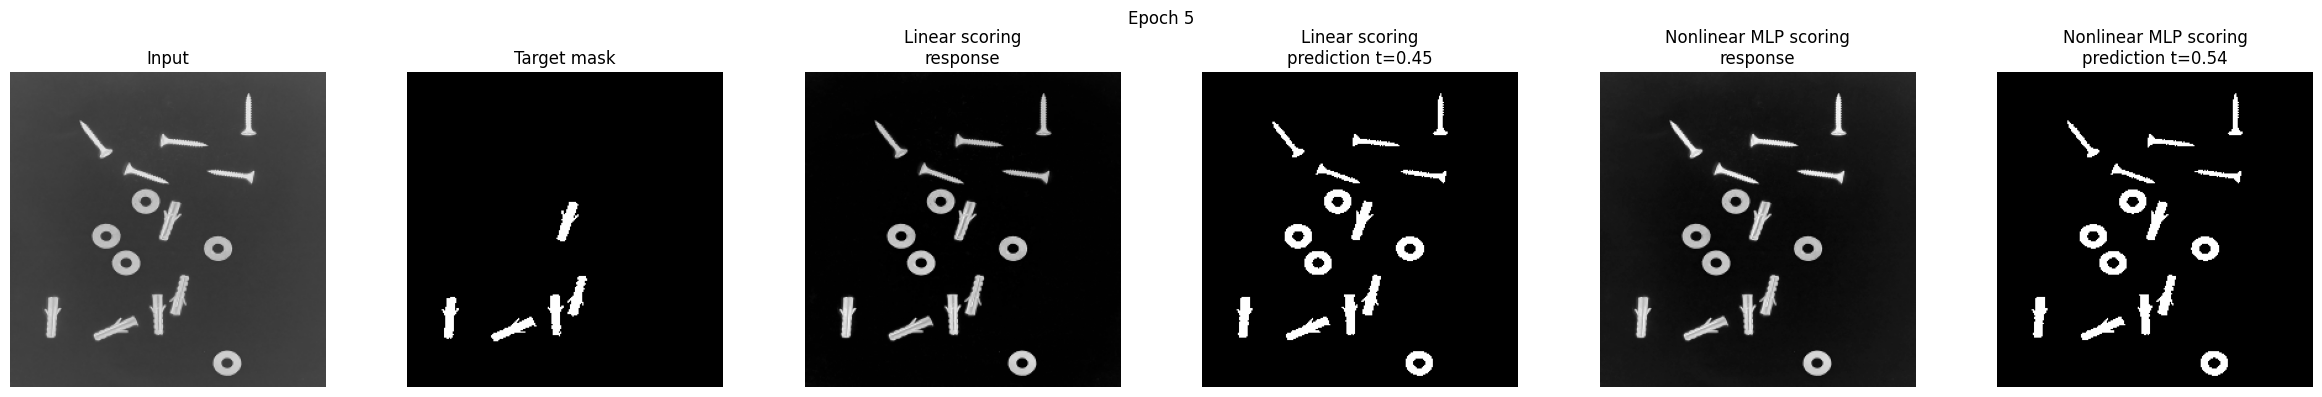

,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,10,Linear scoring,0.451859,0.76,0.496191,0.495480,0.762766,0.796094,0.616509,0.661260
1,10,Nonlinear MLP scoring,0.578400,0.79,0.493719,0.492518,0.683128,0.701873,0.518751,0.540682


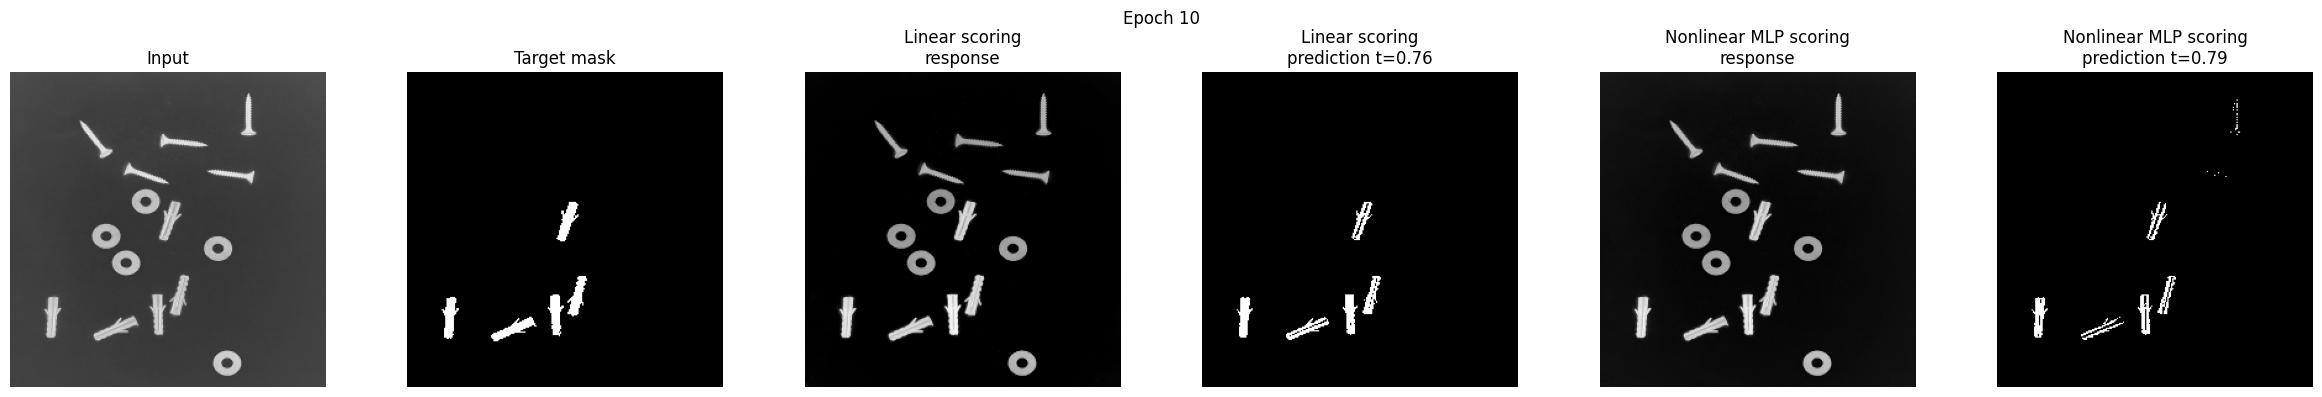

,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,20,Linear scoring,0.354652,0.70,0.718685,0.734432,0.860965,0.884719,0.755872,0.793271
1,20,Nonlinear MLP scoring,0.258484,0.67,0.872814,0.887078,0.903193,0.902758,0.823475,0.822753


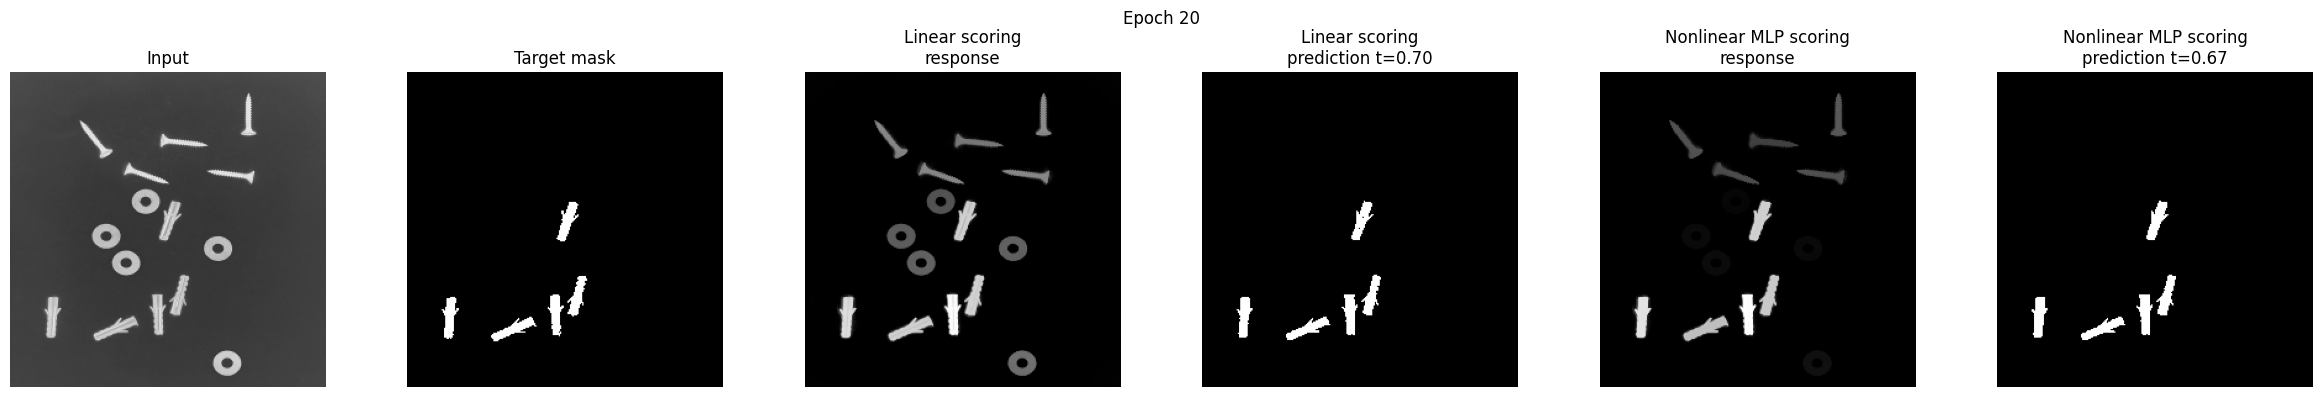

,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,50,Linear scoring,0.290725,0.65,0.849960,0.872864,0.884846,0.890071,0.793474,0.801917
1,50,Nonlinear MLP scoring,0.181254,0.59,0.911809,0.912454,0.913041,0.913285,0.839995,0.840409


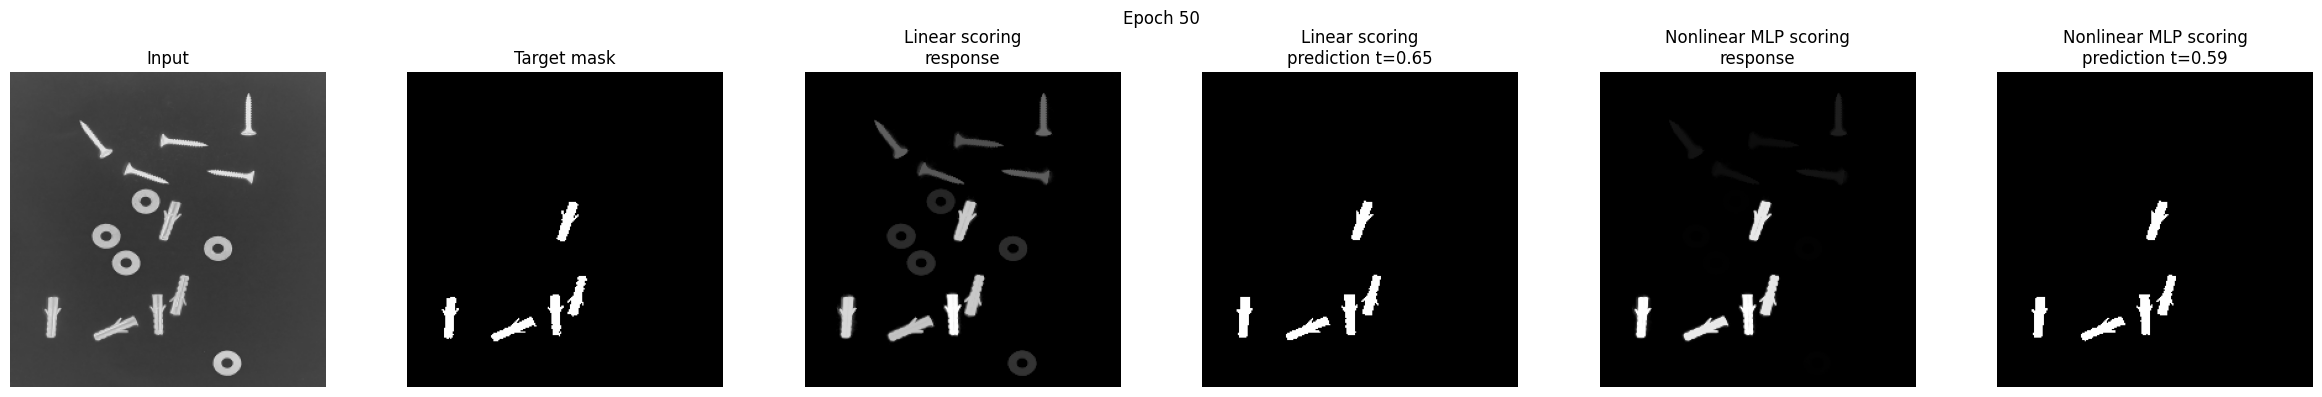

,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,100,Linear scoring,0.258589,0.61,0.891543,0.892609,0.903486,0.908738,0.823962,0.832740
1,100,Nonlinear MLP scoring,0.166966,0.59,0.912180,0.912963,0.913145,0.913590,0.840171,0.840926


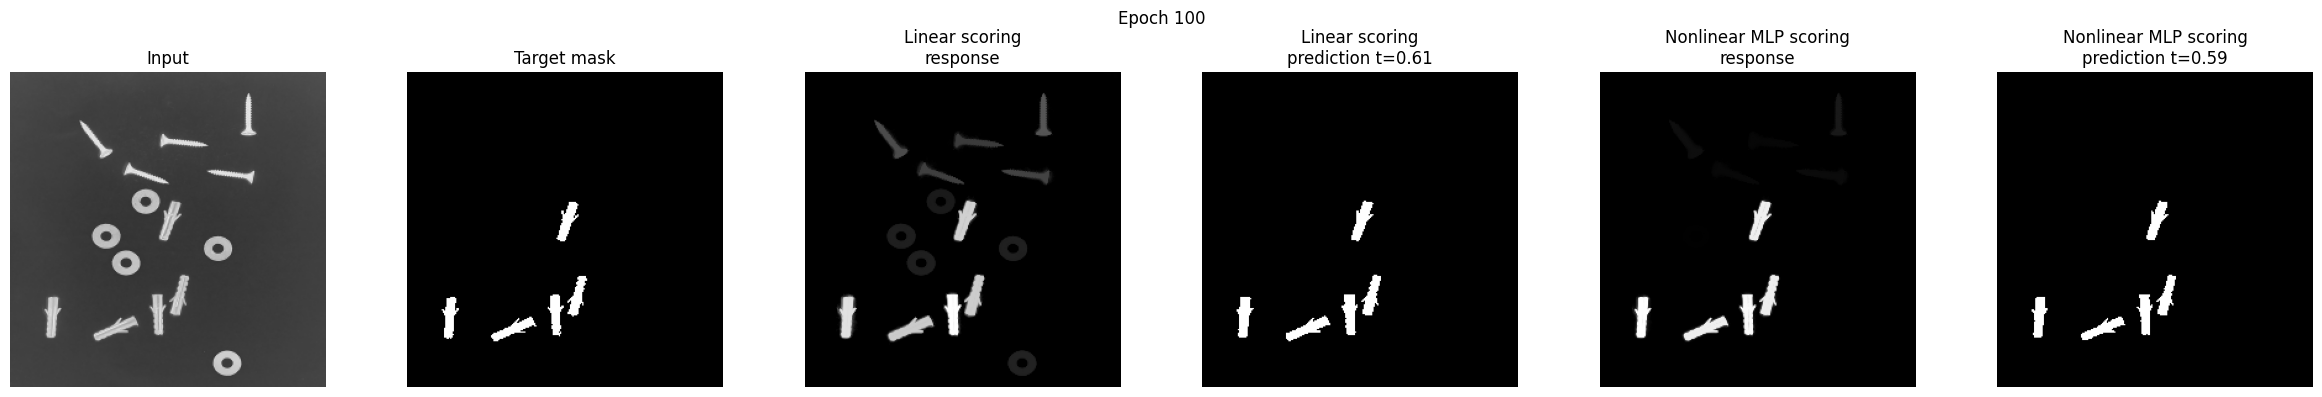

Training completed in 2.136 minutes.


In [19]:
optimizers = {
    model_name: torch.optim.Adam(layer.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for model_name, layer in cfp_layers.items()
}
report_rows = list(initial_rows)
start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = {}

    for model_name, layer in cfp_layers.items():
        layer.train()
        epoch_loss = 0.0
        train_cached = cached_loaders[model_name]["train"]

        for batch_inputs, targets in train_cached:
            response = normalize_per_image(layer(batch_inputs) / OUTPUT_SCALE)
            targets_on_device = targets.to(device=response.device, dtype=response.dtype)
            loss = segmentation_loss(response, targets_on_device)

            optimizers[model_name].zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(layer.parameters(), max_norm=GRAD_CLIP)
            optimizers[model_name].step()

            epoch_loss += loss.item()

        epoch_losses[model_name] = epoch_loss / len(train_cached)

    if epoch in REPORT_EPOCHS:
        epoch_rows = [
            collect_metrics(epoch, model_name, layer, train_loss=epoch_losses[model_name])
            for model_name, layer in cfp_layers.items()
        ]
        report_rows.extend(epoch_rows)
        display(
            pd.DataFrame(epoch_rows)[
                [
                    "epoch",
                    "model",
                    "train_epoch_loss",
                    "threshold",
                    "train_f1_fixed",
                    "test_f1_fixed",
                    "train_f1",
                    "test_f1",
                    "train_iou",
                    "test_iou",
                ]
            ]
        )
        show_segmentation_comparison(epoch=epoch)

elapsed_minutes = (time.time() - start) / 60.0
trajectory = pd.DataFrame(report_rows)
print(f"Training completed in {elapsed_minutes:.3f} minutes.")


## Results

The table and plots compare task fit and parameter growth for the linear and nonlinear scoring models.


,epoch,model,train_epoch_loss,train_loss,test_loss,threshold,train_f1_fixed,test_f1_fixed,train_iou,test_iou,train_f1,test_f1,parameter_l2,num_parameters
0,0,Linear scoring,NaN,0.644072,0.643383,0.52,0.484673,0.483108,0.320413,0.318625,0.485323,0.483268,5.293305,65
1,0,Nonlinear MLP scoring,NaN,0.644072,0.643383,0.52,0.484621,0.483094,0.320413,0.318625,0.485323,0.483268,5.546021,529
2,1,Linear scoring,0.644335,0.643068,0.642470,0.54,0.484739,0.483063,0.320422,0.318893,0.485333,0.483577,5.262375,65
3,1,Nonlinear MLP scoring,0.644582,0.643997,0.643313,0.52,0.484664,0.483132,0.320413,0.318625,0.485323,0.483268,5.545125,529
4,5,Linear scoring,0.557288,0.548329,0.546965,0.45,0.483071,0.481588,0.320195,0.318694,0.485072,0.483348,5.358722,65
5,5,Nonlinear MLP scoring,0.641248,0.639232,0.639130,0.54,0.484827,0.483309,0.320797,0.319097,0.485763,0.483811,6.618313,529
6,10,Linear scoring,0.451859,0.443954,0.440291,0.76,0.496191,0.495480,0.616509,0.661260,0.762766,0.796094,5.710032,65
7,10,Nonlinear MLP scoring,0.578400,0.557570,0.560198,0.79,0.493719,0.492518,0.518751,0.540682,0.683128,0.701873,8.644997,529
8,20,Linear scoring,0.354652,0.352855,0.350373,0.70,0.718685,0.734432,0.755872,0.793271,0.860965,0.884719,6.660789,65
9,20,Nonlinear MLP scoring,0.258484,0.256154,0.257735,0.67,0.872814,0.887078,0.823475,0.822753,0.903193,0.902758,10.797347,529


Final report


,epoch,model,train_epoch_loss,train_loss,test_loss,threshold,train_f1_fixed,test_f1_fixed,train_iou,test_iou,train_f1,test_f1,parameter_l2,num_parameters
12,100,Linear scoring,0.258589,0.261282,0.261558,0.61,0.891543,0.892609,0.823962,0.832740,0.903486,0.908738,11.052208,65
13,100,Nonlinear MLP scoring,0.166966,0.167230,0.167484,0.59,0.912180,0.912963,0.840171,0.840926,0.913145,0.913590,13.448590,529


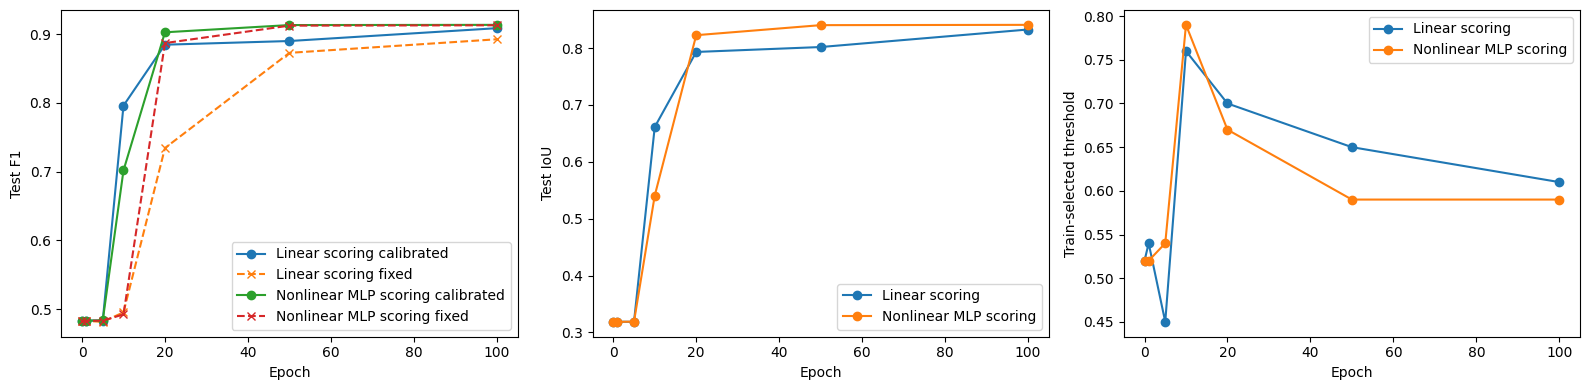

In [20]:
display_columns = [
    "epoch",
    "model",
    "train_epoch_loss",
    "train_loss",
    "test_loss",
    "threshold",
    "train_f1_fixed",
    "test_f1_fixed",
    "train_iou",
    "test_iou",
    "train_f1",
    "test_f1",
    "parameter_l2",
    "num_parameters",
]
display(trajectory[display_columns])

final_rows = trajectory.sort_values("epoch").groupby("model", as_index=False).tail(1)
print("Final report")
display(final_rows[display_columns])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for model_name, group in trajectory.groupby("model"):
    axes[0].plot(group["epoch"], group["test_f1"], marker="o", label=f"{model_name} calibrated")
    axes[0].plot(group["epoch"], group["test_f1_fixed"], linestyle="--", marker="x", label=f"{model_name} fixed")
    axes[1].plot(group["epoch"], group["test_iou"], marker="o", label=model_name)
    axes[2].plot(group["epoch"], group["threshold"], marker="o", label=model_name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test F1")
axes[0].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test IoU")
axes[1].legend()
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Train-selected threshold")
axes[2].legend()
plt.tight_layout()
plt.show()


## Design note

This is a compact scoring-model comparison on the original screws segmentation masks, not a full segmentation benchmark. The two CFP layers differ only in the scoring map from normalized node attributes to scores. The linear scorer is easier to inspect because its weights define an affine gate over attributes. The MLP scorer is more expressive, but its learned rule does not have a direct threshold interpretation.

The loss combines soft Dice and foreground-balanced BCE because the screw foreground is sparse. The threshold used for the main F1/IoU metrics is selected on the training split and then applied to the test split; the fixed-threshold F1 remains in the table as a calibration reference. The morphology backend still builds trees on CPU, while CFP tensors and scorer parameters use the selected `device`.
